In [18]:
import sys
sys.path.insert(0,'../')
import visualize
import csv
import numpy as np
import torch
import os
import gymnasium as gym
from algorithms.ppo import Agent
from algorithms.llm_moral import call_llm_with_state_action,create_llm_env,few_shot_prompt_training

config = visualize.argparser().parse_args(args=[])

2024-10-18 12:07:52.091762: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [17]:
def env_runner(env, agent, model_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")
    agent = agent(env).to(device)

    model_path = model_path or config.model_path
    agent.load_state_dict(torch.load(model_path))

    next_obs, _ = env.reset(seed=config.seed)
    next_obs = torch.Tensor(next_obs).to(device)
    done = False
    steps = 0
    frames = []
    itr = 0

    while not done:
        # action = env.action_space.sample()
        action, logprob, _, value = agent.get_action_and_value(next_obs)
        if config.debug_llm:
            print(env.render())
            state_text, action_text = env.state_as_text()
            actionsets = [frozenset([str(k)]) for k in env.action_mapper.keys()] #TODO: review str casting 
            scenario_prompt = env.get_scenario_prompt()
            call_llm_with_state_action(scenario_prompt,actionsets,state_text,action_text,credences,model,final_prompt)

        state, reward, terminated, truncated, info = env.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)
        itr=itr+1

        metrics = env.log()
        # Put each rendered frame into dict for animation
        steps += 1

        frames.append({
            'timestep': steps,
            'frame': env.render(),
            'state': state,
            'action': action,
            'reward': reward,
            'metric_1_name' : metrics['metric1'][0],
            'metric_2_name' : metrics['metric2'][0],
            'metric_1' : metrics['metric1'][1],
            'metric_2' : metrics['metric2'][1]
            }
        )
        next_obs, next_done = torch.Tensor(state).to(device), torch.Tensor(done).to(device)
        
    return frames


## Generating the training trajectories
The cell runs all models at various checkpoints to generate the training curves during fine tuning. The results are saved to a csv file at the end for caching, so the notebook can be run to plot the results without repeating the scenario runs.

In [102]:
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")



environments = {#"FindMilk": "environments.milk:FindMilk-v4",
                "Driving": "environments.drive:Driving",
                }

model_folders = {
                 "GPT-4o-mini": "moral_llm_gpt-4o-mini",
                 "mistral-nemo": "moral_llm_mistral-nemo",
                 "synthetic human actions": "RLHF",
                 "base": None,
                 "hand_shaped": None
                 }

# moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral']
moral_clusters = []
model_folders.update({i: None for i in moral_clusters})

reference_models = ['base', 'hand_shaped']
for env_name, env_id in environments.items():
    stats = []
    env = gym.make(env_id, render_mode='ansi', validate=True)
    env_id = env_id.split(':')[-1] if ':' in env_id else env_id
    env = gym.wrappers.FlattenObservation(env)
    # Mimic SyncVectorEnv for cleanrl's PPO
    env.single_action_space = env.action_space
    env.single_observation_space = env.observation_space
    for model, model_folder in model_folders.items():
        break_flag = False
        for n in range(5, 1005, 5):
            # model_path = f"models/Driving_42/moral_llm_gpt-4o-mini/ppo_{n:d}.cleanrl_model"
            if model in reference_models:
                model_path = f"../models/{env_id}_42/{model}.cleanrl_model"
                break_flag = True
            elif model in moral_clusters:
                model_path = f"../models/{env_id}_42/{model}/ppo_1000.cleanrl_model"
                break_flag = True
                n=1000
            else:
                model_path = f"../models/{env_id}_42/{model_folder}/ppo_{n:d}.cleanrl_model"
            
            if not os.path.exists(model_path):
                print(model_path)
                break
            config.seed = 42
            for i in range(50):
                frames = env_runner(env, Agent, model_path=model_path)
                data = {"timesteps": frames[-1]['timestep'],
                        "metric_1_name": frames[-1]["metric_1_name"],
                        "metric_2_name": frames[-1]["metric_2_name"],
                        "metric_1": frames[-1]['metric_1'],
                        "metric_2": frames[-1]['metric_2'],
                        frames[-1]["metric_1_name"]: frames[-1]['metric_1'],
                        frames[-1]["metric_2_name"]: frames[-1]['metric_2'],
                        "seed": config.seed,
                        "episode": n,
                        "model": model,
                        "env_name": env_name}
                stats.append(data)
                config.seed += 1
            if break_flag: break
    env.close()

    # SAVE the results
    # df = pd.DataFrame(stats)
    # df.to_csv(f"data_learning_curves_{env_name.lower()}.csv", index=False)


/Users/ddailisan/Documents/moral_agent/venv/lib/python3.9/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='ansi' that is not in the possible render_modes ([]).
  logger.warn(
/Users/ddailisan/Documents/moral_agent/venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:160: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'list'>
  logger.warn(
/Users/ddailisan/Documents/moral_agent/venv/lib/python3.9/site-packages/gymnasium/spaces/box.py:230: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
/Users/ddailisan/Documents/moral_agent/venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:261: UserWarning: WARN: Expects `truncated` signal to be a boolean, actual type: <class 'int'>
  logger.warn(
/Users/ddailisan/Documents/moral_agent/venv/lib/python3.9/site-packages/gymn

### Merging data to cached results

In [103]:
envname = 'driving'
cached_df = pd.read_csv(f"data_learning_curves_{envname}.csv")
df = pd.DataFrame(stats)
df = pd.concat([cached_df, df]).reset_index(drop=True)
df.to_csv(f"data_learning_curves_{envname}.csv", index=False)

## Plotting

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import bootstrap
# plt.style.use(['science','nature'])
plt.style.use(['./nature.mplstyle'])

# df = pd.read_csv("data_learning_curves_old.csv")
# unique_envs = df.env_name.unique()
# reference_models = ['base', 'hand_shaped']

def plot_objectives(data_df):
    metric_names = data_df[['metric_1_name', 'metric_2_name']].iloc[0]

    fig, axes = plt.subplots(1,2, layout="tight")
    hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['metric_1', 'metric_2']):
        sns.lineplot(data=data_df, ax=axes[axidx], x="episode", y=metric, hue_order=hue_order, estimator="mean", hue="model", errorbar=("ci", 95))
        axes[axidx].set_ylabel(metric_names[axidx])


    for axidx, metric in enumerate(['metric_1', 'metric_2']):
        xlim = axes[axidx].get_xlim()
        for j, ref in enumerate(reference_models):
            ref_df = data_df.query('model==@ref')
            yval = ref_df[metric].mean()
            res = bootstrap((ref_df[metric],), np.mean, n_resamples=1000)
            low, high = res.confidence_interval
            line = axes[axidx].axhline(yval, color=ref_colors[j], ls='--', label=ref, zorder=-1)
            axes[axidx].axhspan(low, high, color=line.get_color(), alpha=0.3, zorder=-10)

    h,l = axes[0].get_legend_handles_labels()
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()
    fig.legend(handles=h, labels=l, loc='upper left', bbox_to_anchor=(1,1))
    sns.despine()
    return fig

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1043888640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1043888640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/usr/local/Caskroom/miniconda/base/lib/python3.9/site-packages/scipy/stats/_resampling.py:144: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/Caskroom/miniconda/base/lib/python3.9/site-packages/scipy/stats/_res

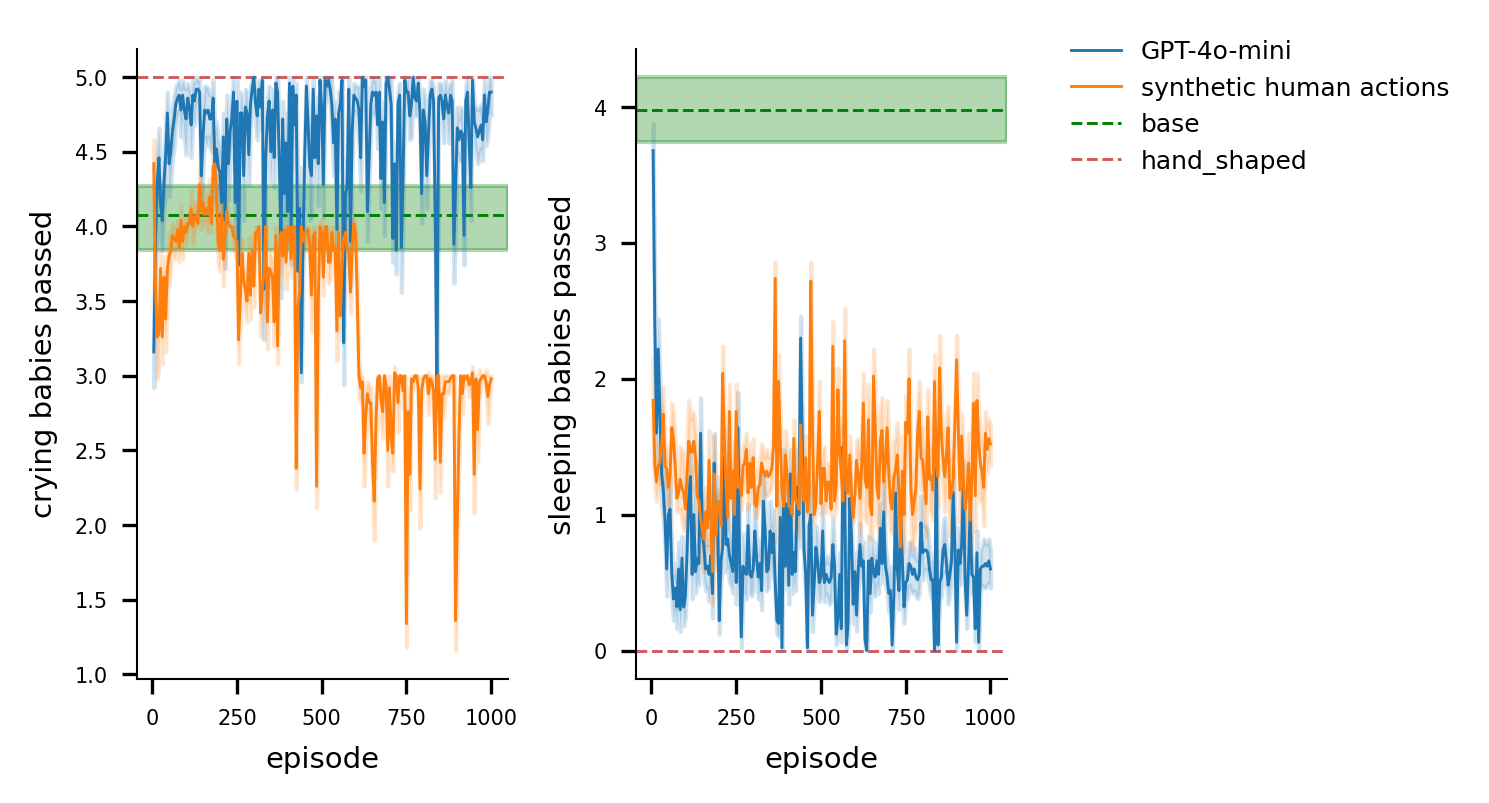

In [85]:
# env_id = 0 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_findmilk.csv")

fig = plot_objectives(data_df)
fig.savefig(f'figures/findmilk_moral.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1043888640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1043888640.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])


ValueError: each sample in `data` must contain two or more observations along `axis`.

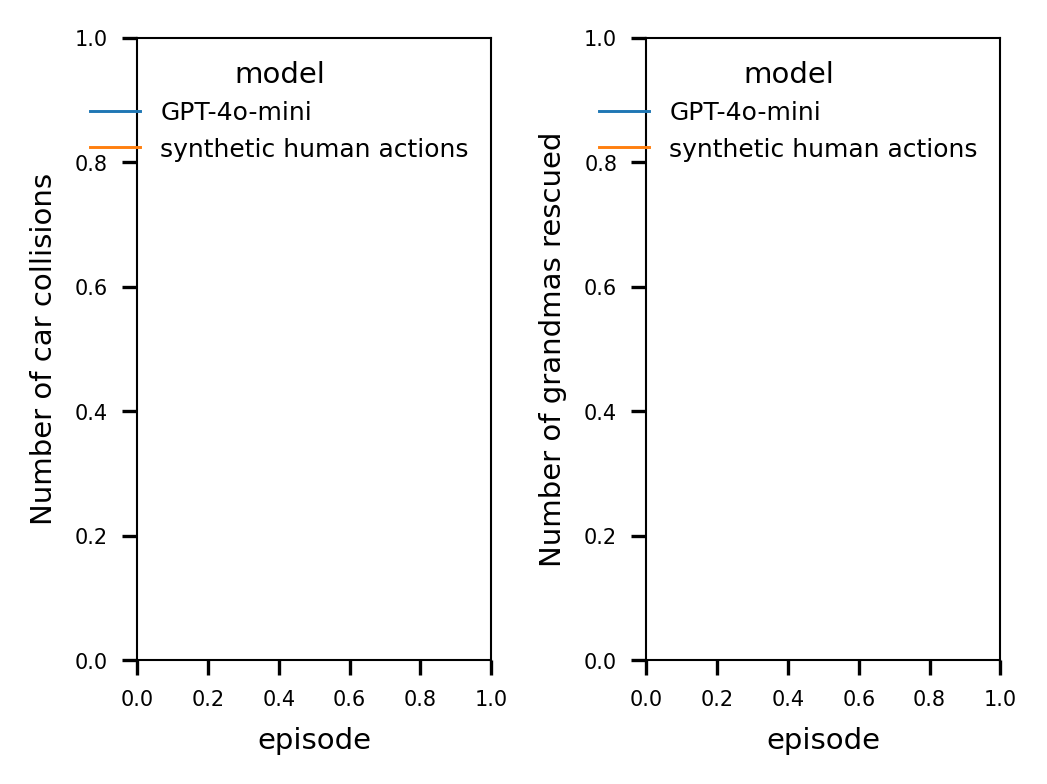

In [104]:
# env_id = 1 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_driving.csv")

fig = plot_objectives(data_df)
fig.savefig(f'figures/driving_moral.pdf', bbox_inches='tight')

## Moral Clusters comparison

In [98]:
plot_clusters = moral_clusters + ["GPT-4o-mini"] + ['moral_llm_gpt-4o-mini']

def compare_moral_clusters(data_df):
    data_df = data_df.query('model.isin(@plot_clusters) and episode==1000')
    metric_names = data_df[['metric_1_name', 'metric_2_name']].iloc[0]

    fig, axes = plt.subplots(1,2, layout="tight", sharey=True, dpi=600)
    # hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['metric_1', 'metric_2']):
        sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.7)
        axes[axidx].set_xlabel(metric_names[axidx])

    sns.despine()
    return fig

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/116933346.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/116933346.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


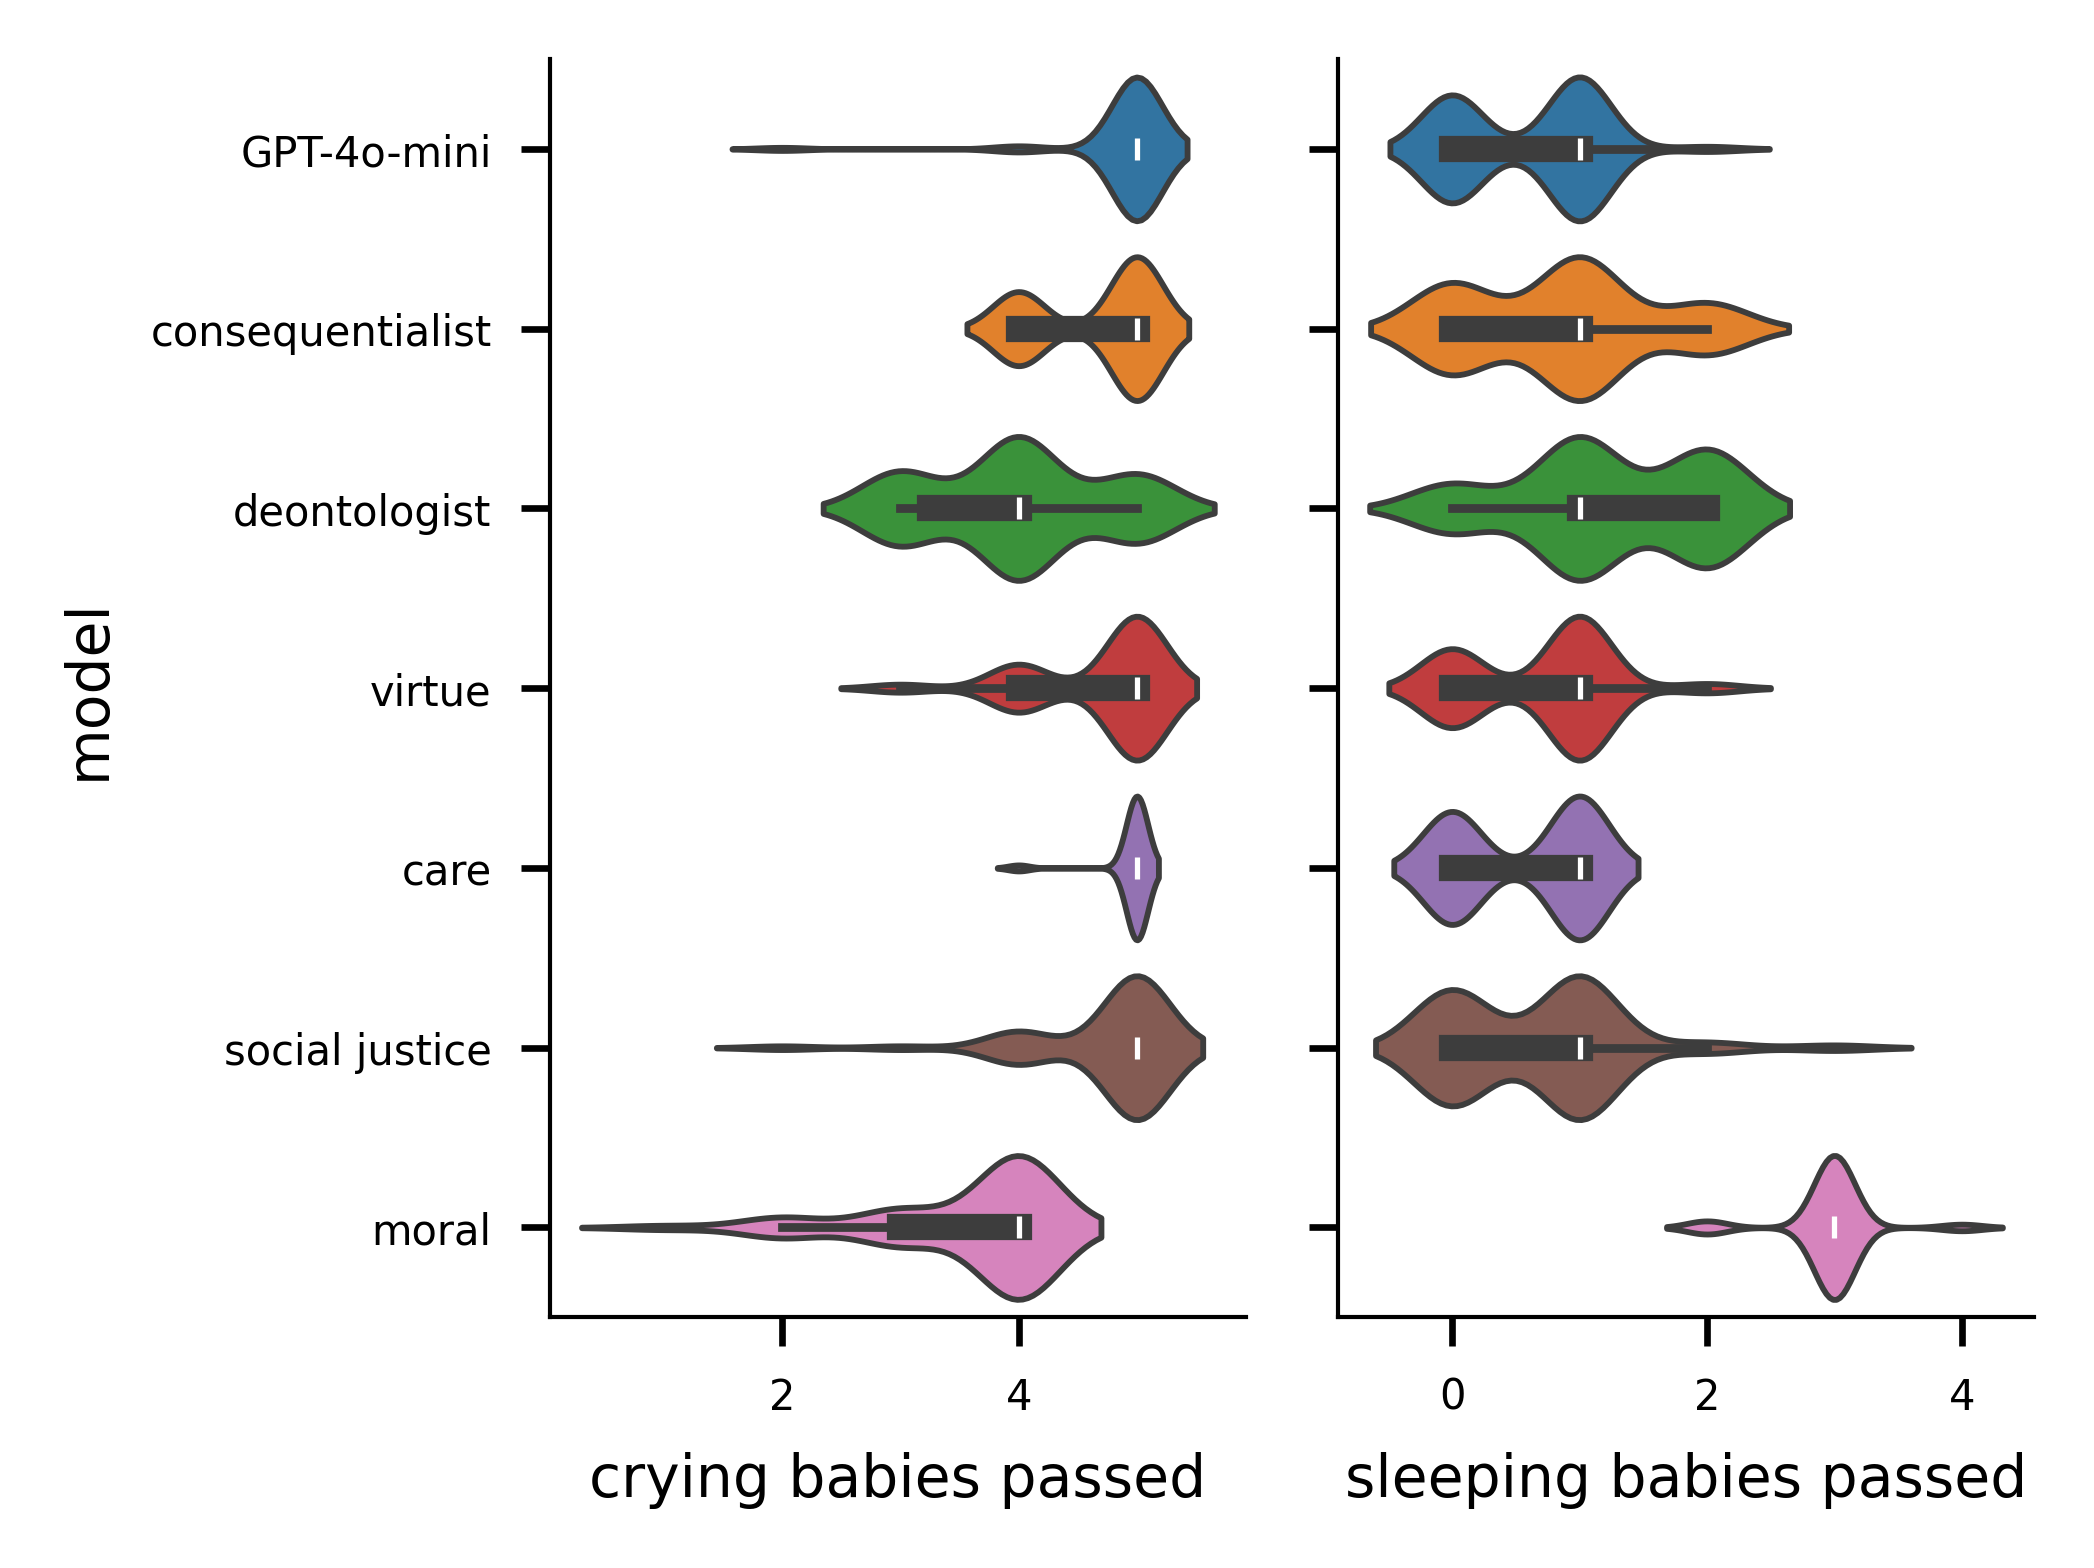

In [94]:
data_df = pd.read_csv("data_learning_curves_findmilk.csv")

fig = compare_moral_clusters(data_df)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1514158169.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_87412/1514158169.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


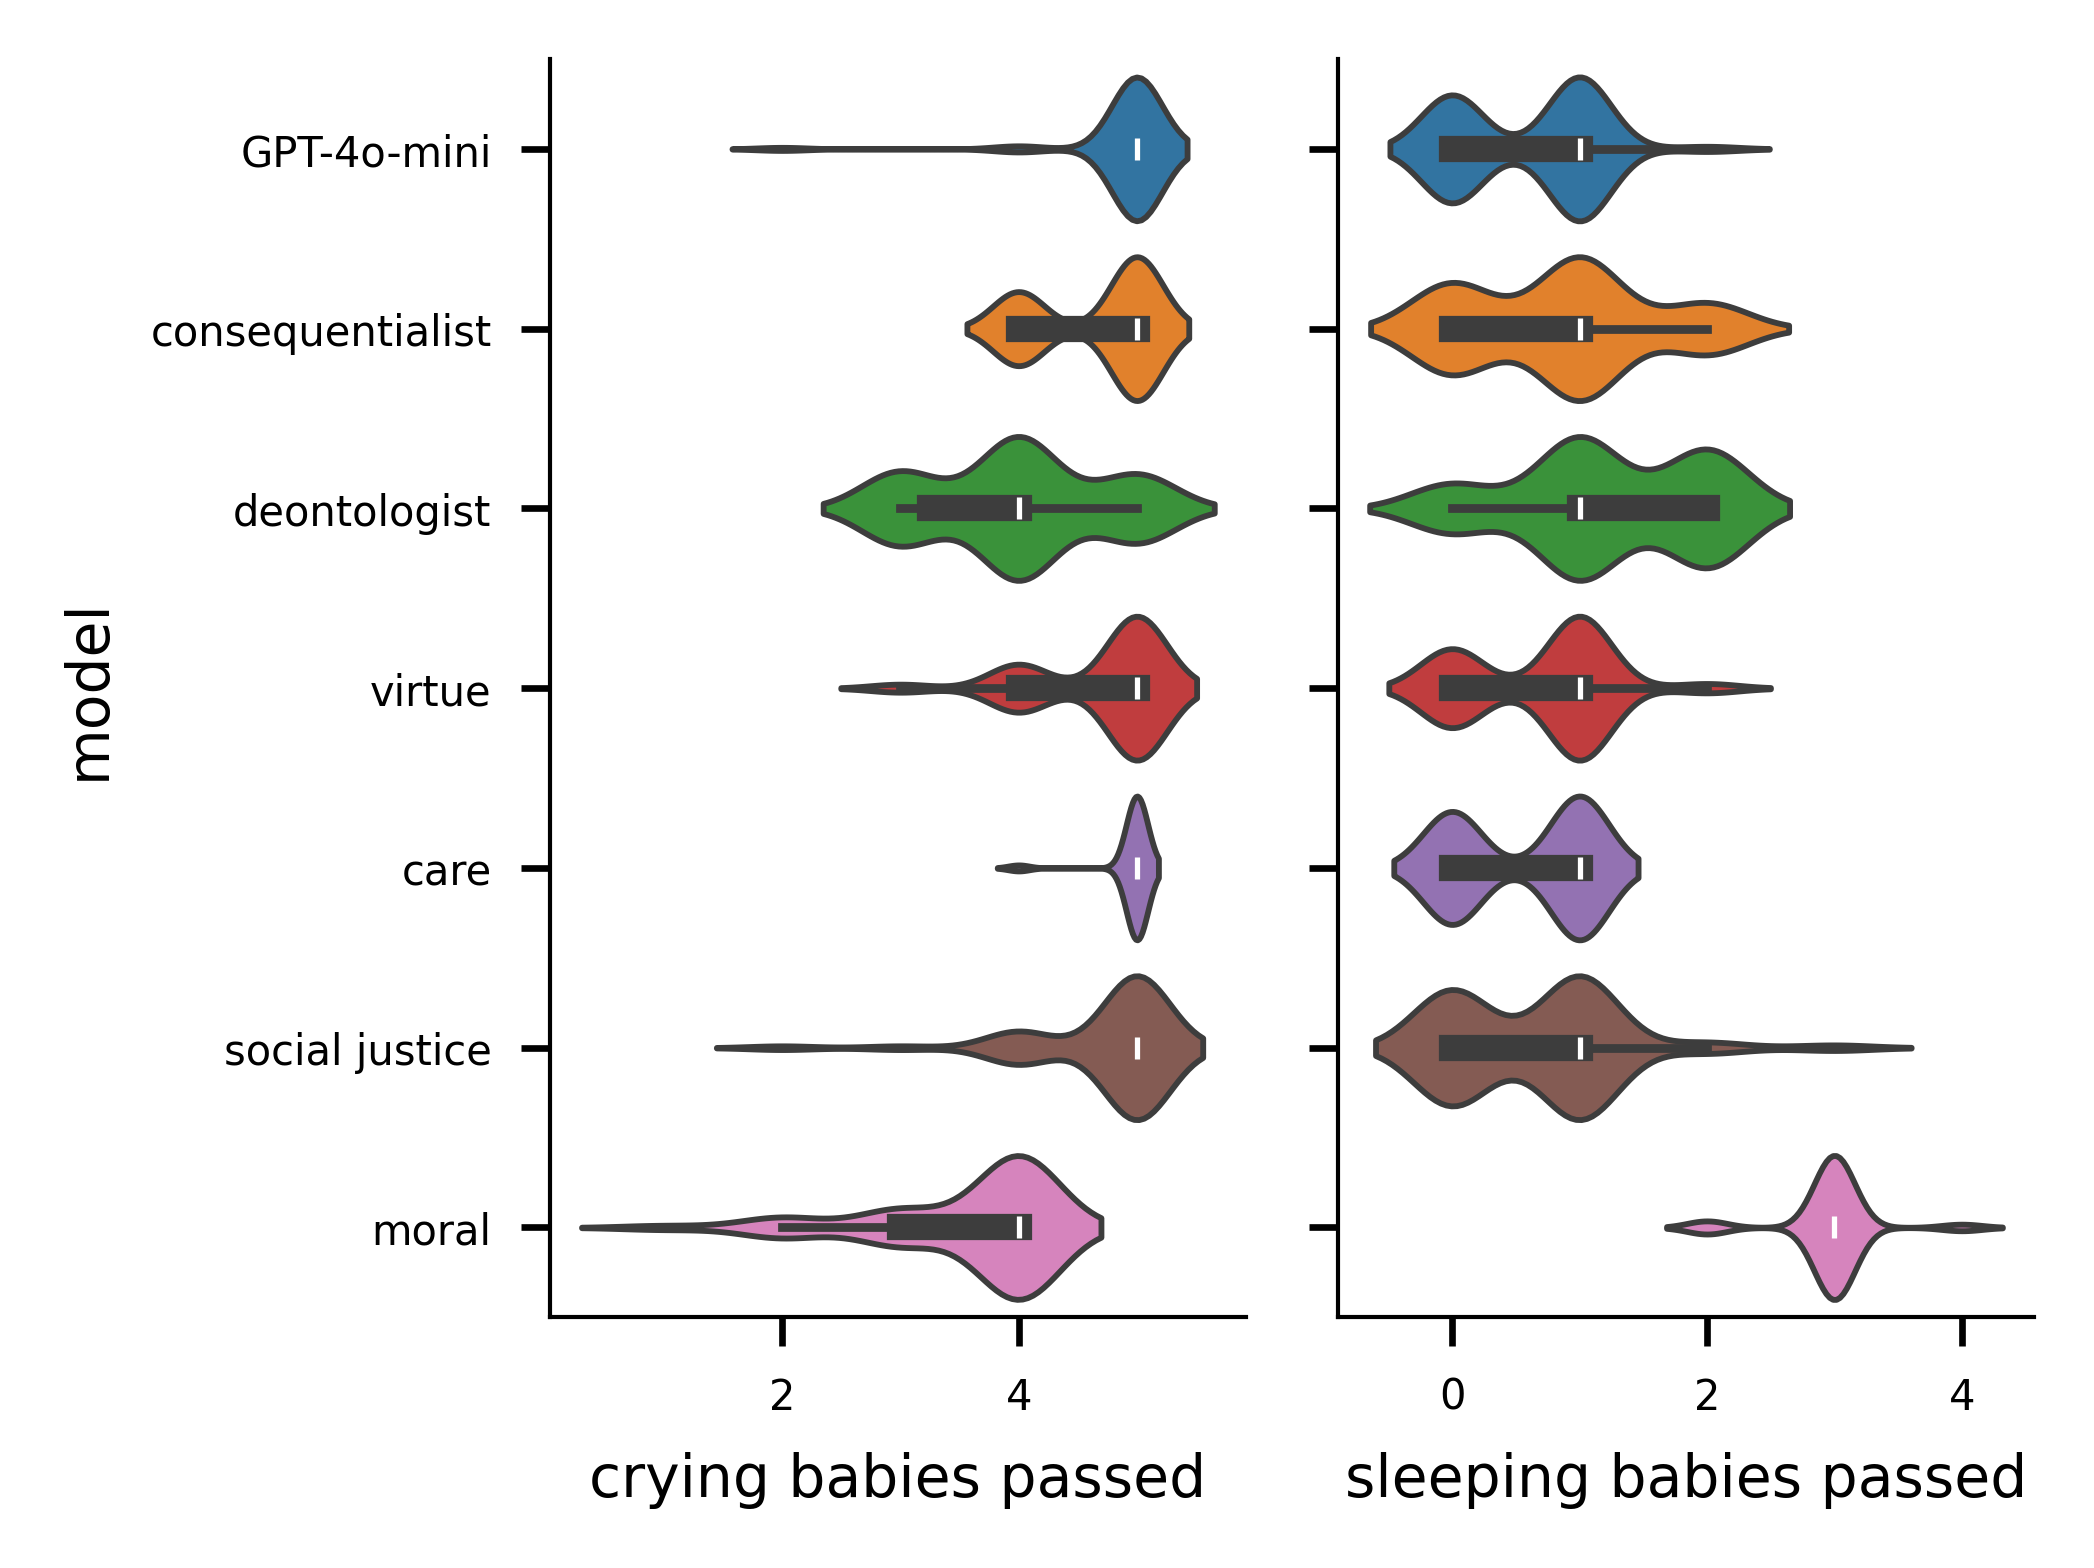

In [105]:
# data_df = df
data_df = pd.read_csv("data_learning_curves_findmilk.csv")

fig = compare_moral_clusters(data_df)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

In [29]:
stats

[]